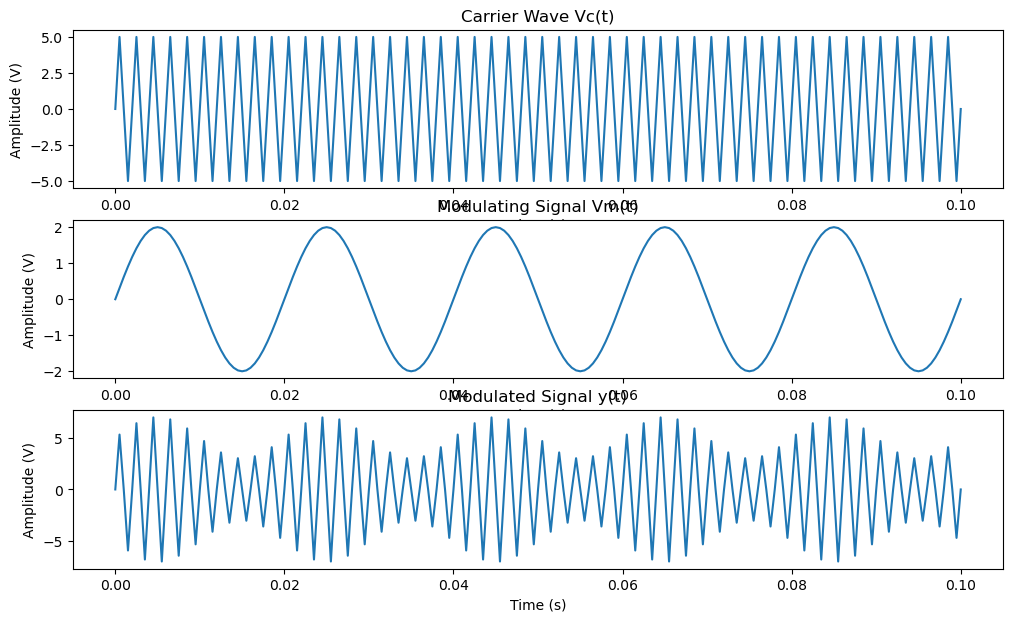

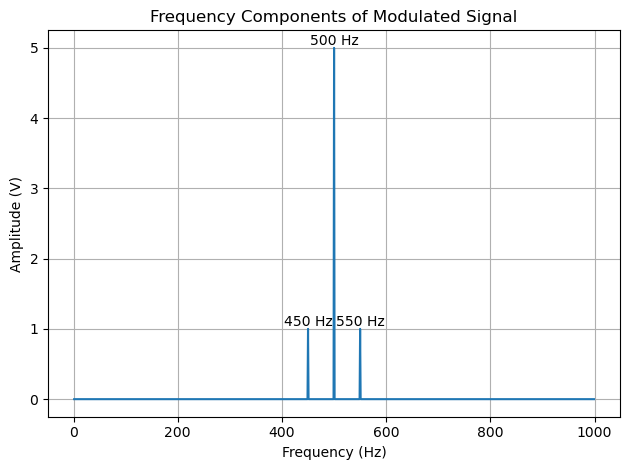

Detected Frequencies and Amplitudes:
Frequency: 450.0 Hz, Amplitude: 1.00 V
Frequency: 500.0 Hz, Amplitude: 5.00 V
Frequency: 550.0 Hz, Amplitude: 1.00 V
ii. Lowest frequency: 450.0 Hz
iii. Highest frequency: 550.0 Hz
iv. Bandwidth: 100.0 Hz


In [20]:
import numpy as np
import matplotlib.pyplot as plt

fs = 2000
t = np.linspace(0, 1, fs, endpoint=False)

#(a) Carrier wave
fc, Ac = 500, 5
sinc = Ac*np.sin(2*np.pi*fc*t)

#(b) Modulating Signal
fm, Am = 50, 2
sinm = Am*np.sin(2*np.pi*fm*t)

#(c) Modulated Signal
y = (Ac + sinm) * np.sin(2 * np.pi * fc * t)

#(d) Plot Vc(t), Vm(t) and y(t) for t in [0, 0.1]
t_plot = t[t <= 0.1] 
plt.figure(figsize=(12, 7))

plt.subplot(3, 1, 1)
plt.plot(t_plot, sinc[t <= 0.1])
plt.title('Carrier Wave Vc(t)')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude (V)')

plt.subplot(3, 1, 2)
plt.plot(t_plot, sinm[t <= 0.1])
plt.title('Modulating Signal Vm(t)')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude (V)')

plt.subplot(3, 1, 3)
plt.plot(t_plot, y[t <= 0.1])
plt.title('Modulated Signal y(t)')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude (V)')
plt.show()

#(e)FFT algorithm
#(i) result plot
fft_result = np.fft.fft(y)
frequencies = np.fft.fftfreq(len(fft_result), 1/fs)
positive_mask = frequencies > 0
positive_frequencies = frequencies[positive_mask]
positive_magnitudes = np.abs(fft_result)[positive_mask] * 2 / fs

plt.plot(positive_frequencies, positive_magnitudes)
plt.title('Frequency Components of Modulated Signal')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude (V)')
plt.grid(True)

#(ii) Lowest frequency
threshold = 0.1
significant_indices = positive_magnitudes > threshold
for freq, amp in zip(positive_frequencies[significant_indices], positive_magnitudes[significant_indices]):
    plt.text(freq, amp, f'{freq:.0f} Hz', ha='center', va='bottom')
plt.tight_layout()
plt.show()

significant_freqs = positive_frequencies[significant_indices]
significant_mags = positive_magnitudes[significant_indices]
print("Detected Frequencies and Amplitudes:")
for freq, amp in zip(significant_freqs, significant_mags):
    print(f"Frequency: {freq:.1f} Hz, Amplitude: {amp:.2f} V")

print(f"ii. Lowest frequency: {min(significant_freqs):.1f} Hz")

#(iii) Highest frequency
print(f"iii. Highest frequency: {max(significant_freqs):.1f} Hz")

#(iv)  Band width based on the Fourier spectrum
print(f"iv. Bandwidth: {(max(significant_freqs) - min(significant_freqs)):.1f} Hz")